In [1]:
import os
import mujoco
import numpy as np
import gymnasium as gym
from gymnasium import spaces
from gymnasium.envs.registration import register
import imageio.v2 as imageio
import matplotlib.pyplot as plt
from IPython.display import Image as IPImage, Video as IPVideo, display

MODEL_PATH = "scene.xml"

In [2]:
class RSArmReachEnv(gym.Env):
    """Gymnasium environment wrapping the MuJoCo rs-arm model (scene.xml).

    The agent applies torques to the 6 arm joints + 2 gripper fingers and is
    rewarded for driving the end-effector site ("ee_site") toward a randomly
    placed target (the mocap body "target").
    """

    metadata = {"render_modes": ["rgb_array"], "render_fps": 50}

    def __init__(self, model_path=MODEL_PATH, render_mode=None,
                 frame_skip=5, max_episode_steps=200,
                 target_radius=(0.25, 0.45), target_z=(0.15, 0.55),
                 success_threshold=0.03, width=640, height=480):
        super().__init__()
        self.model = mujoco.MjModel.from_xml_path(model_path)
        self.data = mujoco.MjData(self.model)

        self.frame_skip = frame_skip
        self.max_episode_steps = max_episode_steps
        self.target_radius = target_radius
        self.target_z = target_z
        self.success_threshold = success_threshold
        self.render_mode = render_mode
        self._elapsed_steps = 0
        self._renderer = None
        self._width, self._height = width, height

        self.ee_site_id = mujoco.mj_name2id(self.model, mujoco.mjtObj.mjOBJ_SITE, "ee_site")
        self.target_body_id = mujoco.mj_name2id(self.model, mujoco.mjtObj.mjOBJ_BODY, "target")
        self.target_mocap_id = self.model.body_mocapid[self.target_body_id]

        ctrl_low = self.model.actuator_ctrlrange[:, 0].copy()
        ctrl_high = self.model.actuator_ctrlrange[:, 1].copy()
        self.action_space = spaces.Box(low=ctrl_low, high=ctrl_high, dtype=np.float64)

        obs_dim = self.model.nq + self.model.nv + 3
        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf, shape=(obs_dim,), dtype=np.float64
        )

    def _get_obs(self):
        ee_pos = self.data.site_xpos[self.ee_site_id]
        target_pos = self.data.mocap_pos[self.target_mocap_id]
        return np.concatenate([
            self.data.qpos.ravel(),
            self.data.qvel.ravel(),
            target_pos - ee_pos,
        ]).astype(np.float64)

    def _sample_target(self):
        r = self.np_random.uniform(*self.target_radius)
        theta = self.np_random.uniform(-np.pi * 0.6, np.pi * 0.6)  # stay in front of the base
        z = self.np_random.uniform(*self.target_z)
        return np.array([r * np.cos(theta), r * np.sin(theta), z])

    def reset(self, *, seed=None, options=None):
        super().reset(seed=seed)
        mujoco.mj_resetData(self.model, self.data)

        # small random perturbation around the home pose, clipped to joint limits
        noise = self.np_random.uniform(-0.05, 0.05, size=self.model.nq)
        qpos = np.clip(noise, self.model.jnt_range[:, 0], self.model.jnt_range[:, 1])
        self.data.qpos[:] = qpos

        self.data.mocap_pos[self.target_mocap_id] = self._sample_target()

        mujoco.mj_forward(self.model, self.data)
        self._elapsed_steps = 0

        return self._get_obs(), {}

    def step(self, action):
        action = np.clip(action, self.action_space.low, self.action_space.high)
        self.data.ctrl[:] = action
        for _ in range(self.frame_skip):
            mujoco.mj_step(self.model, self.data)
        self._elapsed_steps += 1

        ee_pos = self.data.site_xpos[self.ee_site_id]
        target_pos = self.data.mocap_pos[self.target_mocap_id]
        distance = float(np.linalg.norm(ee_pos - target_pos))

        reward = -distance - 1e-3 * float(np.square(action).sum())
        terminated = distance < self.success_threshold
        truncated = self._elapsed_steps >= self.max_episode_steps
        if terminated:
            reward += 10.0

        obs = self._get_obs()
        info = {"distance": distance, "is_success": terminated}
        return obs, reward, terminated, truncated, info

    def render(self):
        if self._renderer is None:
            self._renderer = mujoco.Renderer(self.model, height=self._height, width=self._width)
        self._renderer.update_scene(self.data, camera=-1)
        return self._renderer.render()

    def close(self):
        if self._renderer is not None:
            self._renderer.close()
            self._renderer = None


register(id="RSArmReach-v0", entry_point=RSArmReachEnv, max_episode_steps=200)

In [3]:
env = gym.make("RSArmReach-v0")

print("action_space:", env.action_space)
print("observation_space:", env.observation_space)

obs, info = env.reset(seed=0)
print("obs shape:", obs.shape, "example obs[:5]:", obs[:5])

action_space: Box([ -36.  -36.  -36.  -14.  -14.  -14. -500. -500.], [ 36.  36.  36.  14.  14.  14. 500. 500.], (8,), float64)
observation_space: Box(-inf, inf, (19,), float64)
obs shape: (19,) example obs[:5]: [ 0.01369617  0.          0.         -0.04834724  0.03132702]


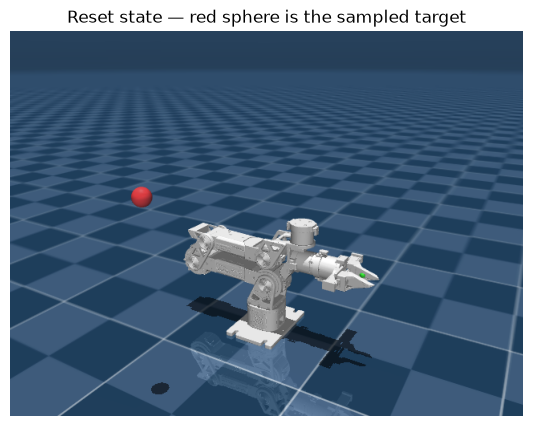

In [4]:
obs, info = env.reset(seed=1)
frame = env.render()

plt.figure(figsize=(7, 5))
plt.imshow(frame)
plt.axis("off")
plt.title("Reset state — red sphere is the sampled target")
plt.show()

## Replay

In [7]:
import pandas as pd
import cv2

DATASET_DIR = r"C:\Users\jinhe\Downloads\orange-fixed_4\orange-fixed_4"
EPISODE = 0

data_df = pd.read_parquet(f"{DATASET_DIR}/data/chunk-000/file-000.parquet")
episodes_df = pd.read_parquet(f"{DATASET_DIR}/meta/episodes/chunk-000/file-000.parquet")

ep_row = episodes_df[episodes_df["episode_index"] == EPISODE].iloc[0]
ep_data = data_df[data_df["episode_index"] == EPISODE].reset_index(drop=True)

state = np.stack(ep_data["observation.state"].to_numpy())   # (T, 7) degrees
action = np.stack(ep_data["action"].to_numpy())              # (T, 7) degrees
timestamps = ep_data["timestamp"].to_numpy()

joint_names = ["shoulder_pan", "shoulder_lift", "elbow_flex", "wrist_flex", "wrist_yaw", "wrist_roll", "gripper"]

print(f"episode {EPISODE}: task={ep_row['tasks']!r}, length={ep_row['length']} frames, "
      f"video chunk/file={ep_row['videos/observation.images.front/chunk_index']}/"
      f"{ep_row['videos/observation.images.front/file_index']}, "
      f"video time range=[{ep_row['videos/observation.images.front/from_timestamp']:.2f}, "
      f"{ep_row['videos/observation.images.front/to_timestamp']:.2f}]s")
print("state shape:", state.shape, " frame-0 state:", state[0])

episode 0: task=array(['Grab the black cube'], dtype=object), length=599 frames, video chunk/file=0/0, video time range=[0.00, 19.97]s
state shape: (599, 7)  frame-0 state: [0. 0. 0. 0. 0. 0. 0.]


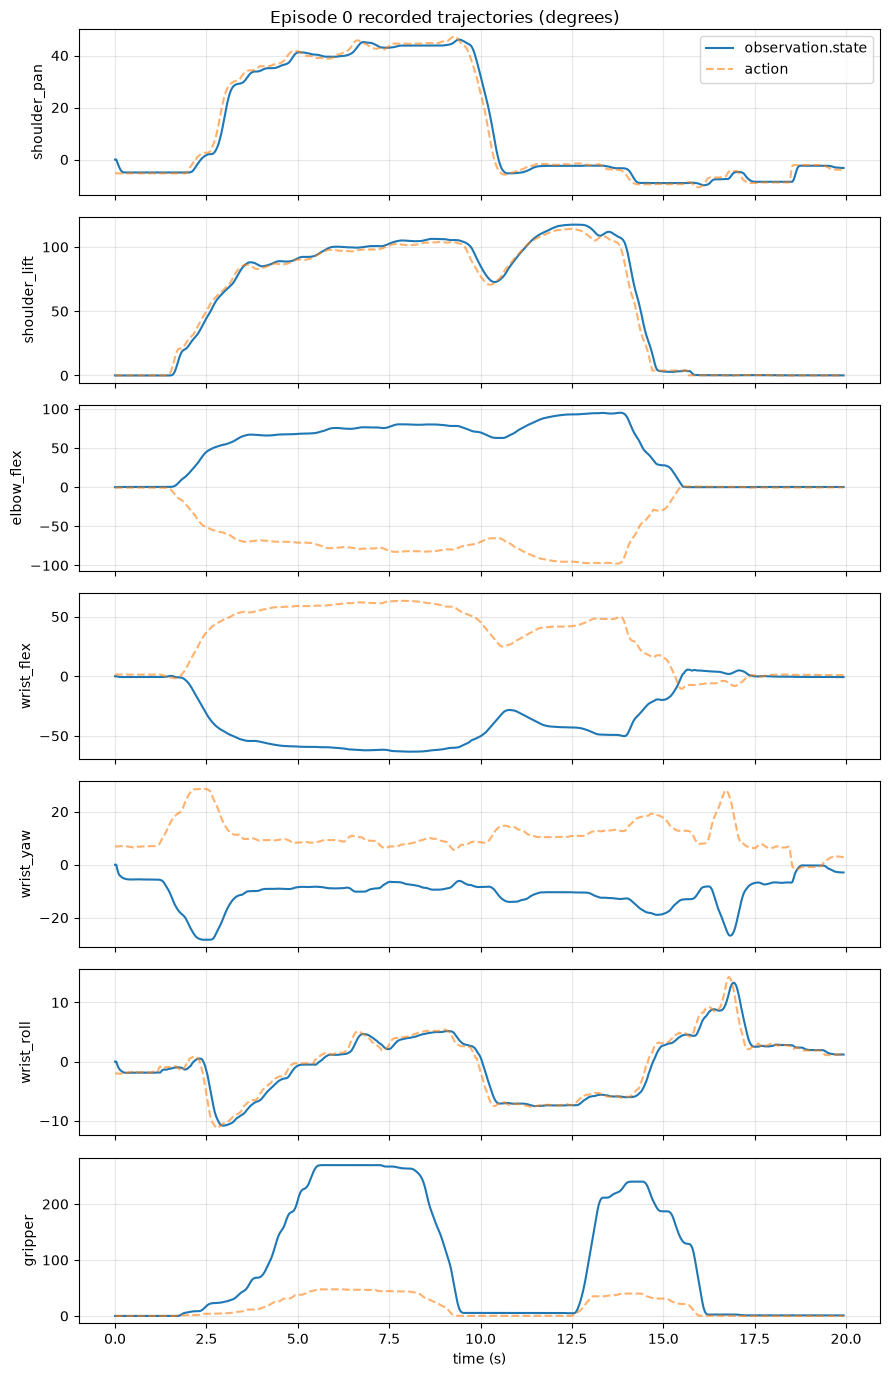

In [8]:
fig, axes = plt.subplots(7, 1, figsize=(9, 14), sharex=True)
for i, ax in enumerate(axes):
    ax.plot(timestamps, state[:, i], label="observation.state")
    ax.plot(timestamps, action[:, i], label="action", alpha=0.6, linestyle="--")
    ax.set_ylabel(joint_names[i])
    ax.grid(alpha=0.3)
axes[0].legend(loc="upper right")
axes[-1].set_xlabel("time (s)")
fig.suptitle(f"Episode {EPISODE} recorded trajectories (degrees)")
plt.tight_layout()
plt.show()

In [9]:
# fresh model instance for replay (kept separate from the gym `env` above)
replay_model = mujoco.MjModel.from_xml_path("scene.xml")
replay_data = mujoco.MjData(replay_model)

arm_jnt_range = replay_model.jnt_range[:6].copy()
gripper_deg_min, gripper_deg_max = state[:, 6].min(), state[:, 6].max()

# hide the RL-task target sphere for this replay — it's not relevant to kinematic replay
target_body_id = mujoco.mj_name2id(replay_model, mujoco.mjtObj.mjOBJ_BODY, "target")
for g in range(replay_model.ngeom):
    if replay_model.geom_bodyid[g] == target_body_id:
        replay_model.geom_rgba[g, 3] = 0.0

front_cam_id = mujoco.mj_name2id(replay_model, mujoco.mjtObj.mjOBJ_CAMERA, "front_like")


def state_row_to_qpos(row):
    """Map one (7,) observation.state row [degrees] to an (8,) sim qpos."""
    qpos = np.zeros(8)
    qpos[:6] = np.clip(np.deg2rad(row[:6]), arm_jnt_range[:, 0], arm_jnt_range[:, 1])
    grip_frac = np.clip((row[6] - gripper_deg_min) / (gripper_deg_max - gripper_deg_min + 1e-9), 0, 1)
    qpos[6] = grip_frac * replay_model.jnt_range[6, 1]  # gripper_joint1 upper limit
    qpos[7] = grip_frac * replay_model.jnt_range[7, 1]  # gripper_joint2 upper limit
    return qpos


print("per-joint recorded range (rad)  vs  URDF jnt_range (rad):")
for i, name in enumerate(["joint1", "joint2", "joint3", "joint4", "joint5", "joint6"]):
    rad = np.deg2rad(state[:, i])
    print(f"  {name:8s} data=[{rad.min():+.2f}, {rad.max():+.2f}]   urdf={arm_jnt_range[i]}")

per-joint recorded range (rad)  vs  URDF jnt_range (rad):
  joint1   data=[-0.17, +0.80]   urdf=[-2.8  2.8]
  joint2   data=[-0.00, +2.05]   urdf=[0.   3.14]
  joint3   data=[-0.00, +1.66]   urdf=[0.   3.14]
  joint4   data=[-1.10, +0.10]   urdf=[-1.57  1.57]
  joint5   data=[-0.49, +0.00]   urdf=[-1.57  1.57]
  joint6   data=[-0.19, +0.23]   urdf=[-3.14  3.14]


In [10]:
FRONT_VIDEO_PATH = f"{DATASET_DIR}/videos/observation.images.front/chunk-000/file-000.mp4"
FRAME_STRIDE = 2  # subsample 30fps -> 15fps to keep the output small
PANEL_SIZE = (480, 360)  # (width, height) per panel

video_start_frame = round(ep_row["videos/observation.images.front/from_timestamp"] * 30)
replay_renderer = mujoco.Renderer(replay_model, height=PANEL_SIZE[1], width=PANEL_SIZE[0])

cap = cv2.VideoCapture(FRONT_VIDEO_PATH)
cap.set(cv2.CAP_PROP_POS_FRAMES, video_start_frame)

combo_frames = []
for idx in range(0, len(state), FRAME_STRIDE):
    # sim panel: kinematic replay of the recorded state
    replay_data.qpos[:] = state_row_to_qpos(state[idx])
    mujoco.mj_forward(replay_model, replay_data)
    replay_renderer.update_scene(replay_data, camera=front_cam_id)
    sim_panel = replay_renderer.render()

    # real panel: matching frame from the front camera
    ret, real_frame = cap.read()
    if not ret:
        break
    real_panel = cv2.resize(cv2.cvtColor(real_frame, cv2.COLOR_BGR2RGB), PANEL_SIZE)

    combo_frames.append(np.concatenate([real_panel, sim_panel], axis=1))

    for _ in range(FRAME_STRIDE - 1):
        if not cap.grab():
            break
cap.release()

print(f"built {len(combo_frames)} side-by-side frames (real | sim)")

compare_path = "rs_arm_episode0_real_vs_sim.mp4"
imageio.mimsave(compare_path, combo_frames, fps=30 // FRAME_STRIDE, macro_block_size=None)
print("saved:", compare_path, f"({os.path.getsize(compare_path) / 1e6:.1f} MB)")

built 300 side-by-side frames (real | sim)


saved: rs_arm_episode0_real_vs_sim.mp4 (1.3 MB)


In [11]:
display(IPVideo(compare_path, embed=True, width=960))
replay_renderer.close()

# Potential next steps

In [9]:
# We want to simulate the policy using the torque and action states of the simulation and video feeds of orange-fixed_4

## Training a traditional policy

In [ ]:
# We want to create a config file of {"orange": est_diameter, location1, location2}
# Train a policy using sim to move object from location1 to location2

# Run the full thing over all objects sequentially (like motion planning)